# Prédiction de Séries Temporelles avec RNNs

## Chargement et Exploration des Données Fournies

* Chargez le jeu de données temporel assigné.
* Explorez-le : structure, fréquence des données, tendances, saisonnalités (visualisation graphique essentielle), présence de valeurs manquantes.

In [1]:
# --- Importation ---
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from tensorflow.keras import layers, models, optimizers, metrics, callbacks

# --- Configuration ---

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# --- Download dataset ---

# fetch dataset
dataset = fetch_ucirepo(id=235)
df = dataset.data.features

print("Structure des variables selon le fournisseur :\n")
print(dataset.variables)

C:\Users\ttheu\OneDrive\Documents\2025-2026\Q2\Framework-MachineLearning\MASI4_Framework_Machine_Learning\.venv\lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Structure des variables selon le fournisseur :

                    name     role         type demographic description units  \
0                   Date  Feature         Date        None        None  None   
1                   Time  Feature  Categorical        None        None  None   
2    Global_active_power  Feature   Continuous        None        None  None   
3  Global_reactive_power  Feature   Continuous        None        None  None   
4                Voltage  Feature   Continuous        None        None  None   
5       Global_intensity  Feature   Continuous        None        None  None   
6         Sub_metering_1  Feature   Continuous        None        None  None   
7         Sub_metering_2  Feature   Continuous        None        None  None   
8         Sub_metering_3  Feature   Continuous        None        None  None   

  missing_values  
0             no  
1             no  
2             no  
3             no  
4             no  
5             no  
6             no  

In [2]:
# --- Exploration initiale ---

print("Dimensions du dataframe brut :")
print(df.shape)

print("Liste des colonnes et types initiaux :")
display(df.dtypes.to_frame("dtype").T)

print("Aperçu du dataframe brut :")
display(df.head())

print("Informations générales :")
display(df.describe(include="all"))

Dimensions du dataframe brut :
(2075259, 9)
Liste des colonnes et types initiaux :


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dtype,object,object,object,object,object,object,object,object,float64


Aperçu du dataframe brut :


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


Informations générales :


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2075259,2075259,2075259,2075259,2075259,2075259,2075259,2075259,2.049280e+06
unique,1442,1440,6534,896,5168,377,153,145,NaN
top,25/11/2010,20:24:00,?,0.000,?,1.000,0.000,0.000,NaN
freq,1440,1442,25979,472786,25979,169406,1840611,1408274,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.458447e+00
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.437154e+00
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.700000e+01


## Prétraitement Spécifique aux Séries Temporelles (Étapes Clés)

* **Nettoyage** : Gérez les valeurs manquantes (imputation simple ou interpolation, justifiez).
* **Normalisation/Standardisation** : Mettez à l'échelle les valeurs numériques. Discutez de la stratégie : normaliser sur tout le set d'entraînement ou par fenêtre ?
* **Windowing (Fenêtrage)** : Transformez la série temporelle en un jeu de données supervisé en créant des fenêtres glissantes. Chaque fenêtre contiendra une séquence d'entrée (les N valeurs passées) et une cible de sortie (la valeur M pas de temps plus tard - souvent M=1 pour prédire la prochaine valeur). Utilisez `tf.data.Dataset.window` ou des techniques NumPy/Pandas. Justifiez la taille de la fenêtre choisie.
* **Préparation Finale** : Séparez vos données fenêtrées en ensembles d'entraînement, de validation et de test (attention à ne pas mélanger le temps lors de la séparation ! La validation et le test doivent venir après l'entraînement dans le temps).

**Prétraitement Séries Temporelles** :
* Normalisation : Quand et comment normaliser (avant/après windowing, sur quelles données) ?
* Windowing : Comprendre comment créer des fenêtres d'entrée/sortie. Explorer l'utilisation de `tf.data.Dataset.window`, `.flat_map`, `.batch` ou des alternatives NumPy/Pandas. Impact de la taille de la fenêtre.

**Architectures RNN** :
* Limitations SimpleRNN pour dépendances longues.
* Rôle des portes LSTM/GRU.
* Intérêt de Bidirectional (est-ce pertinent pour la prédiction future ? Discutez-en).

**Évaluation Régression** : Comprendre les métriques MSE, MAE, RMSE et leur interprétation. Savoir visualiser et analyser les prédictions vs les valeurs réelles.

Types après conversion :


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dtype,float64,float64,float64,float64,float64,float64,float64


Valeurs manquantes avant interpolation :
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64
Dimensions avant rééchantillonnage : (2075259, 7)
Dimensions après rééchantillonnage horaire : (34589, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,month,dayofyear,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
Datetime,,,,,,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,12,350,1,-0.965926,-2.588190e-01,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,12,350,1,-1.000000,-1.836970e-16,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,12,350,1,-0.965926,2.588190e-01,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,12,350,1,-0.866025,5.000000e-01,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,12,350,1,-0.707107,7.071068e-01,-0.974928,-0.222521,-2.449294e-16,1.0


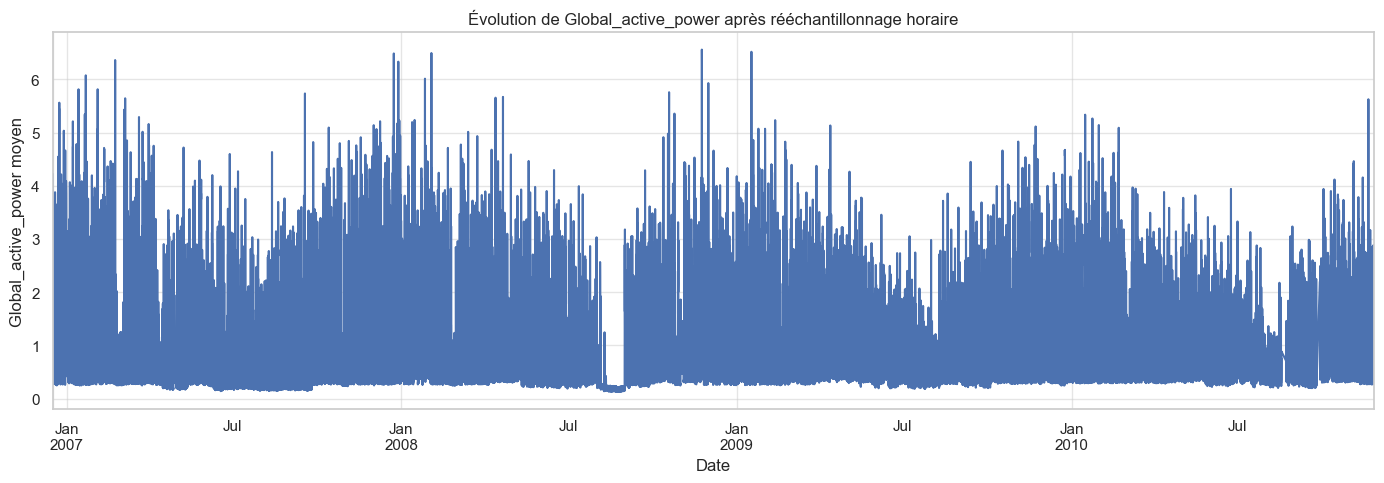

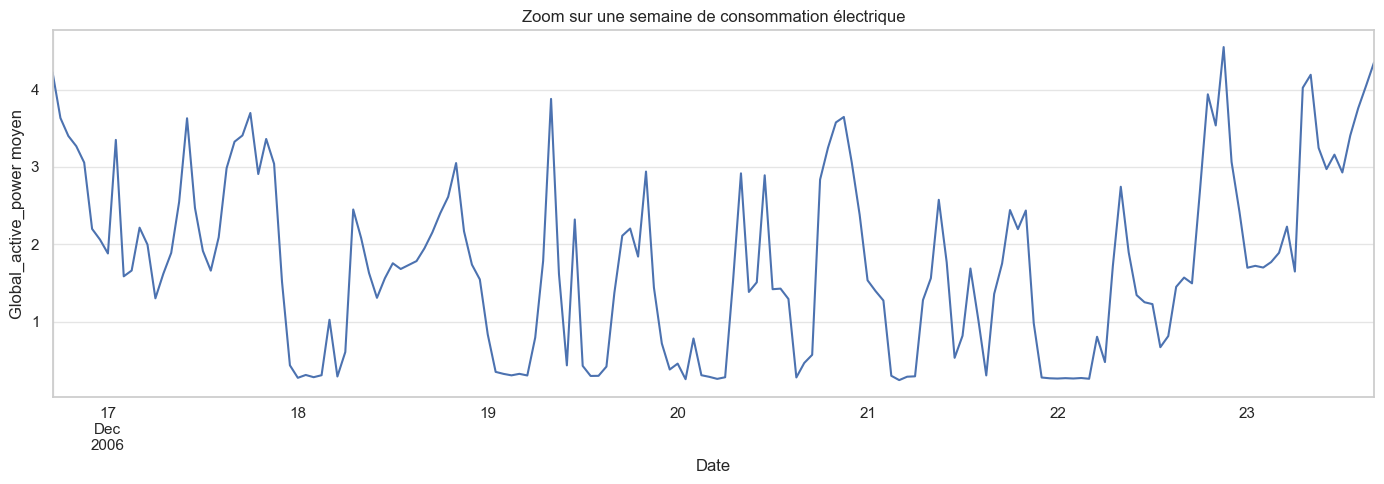

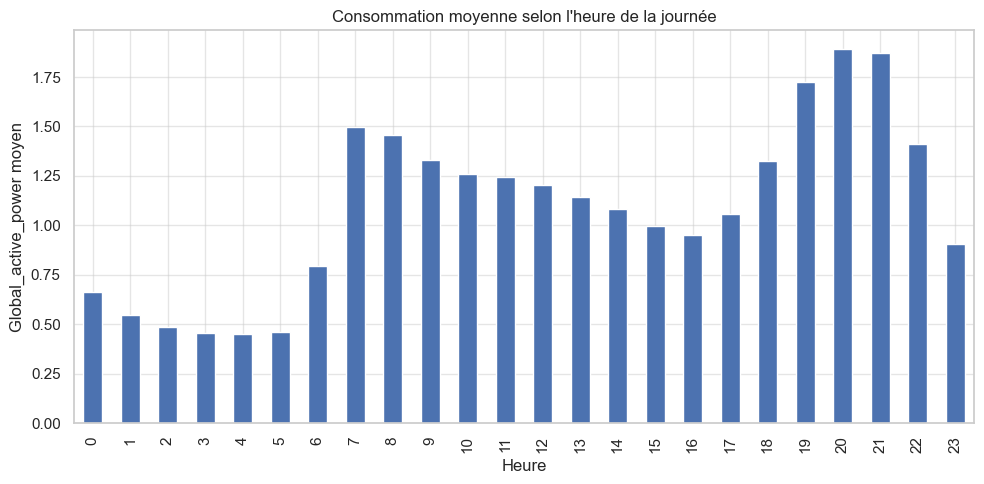

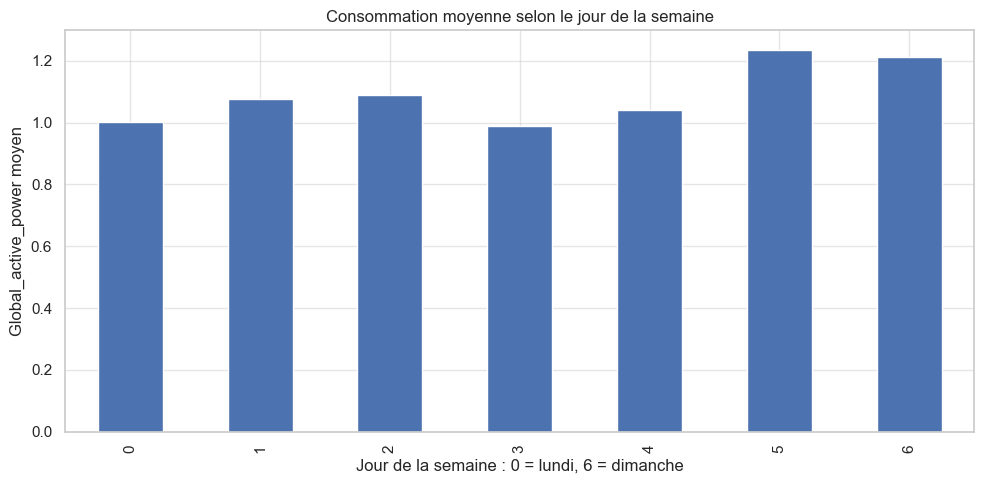

In [3]:
# --- Nettoyage des valeurs manquantes et conversion des types ---

# Remplacer les '?' par NaN
df = df.replace("?", np.nan)

# Créer un index temporel à partir de Date + Time
df["Datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True,
    errors="coerce"
)

# Mettre Datetime en index
df = df.set_index("Datetime").sort_index()

# Supprimer les colonnes texte initiales
df = df.drop(columns=["Date", "Time"])

# Colonnes numériques du dataset original
cols_to_fix = ["Global_active_power","Global_reactive_power","Voltage","Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"]

# Conversion en numérique
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- Afficher les données après transformation ---

print("Types après conversion :")
display(df.dtypes.to_frame("dtype").T)

print("Valeurs manquantes avant interpolation :")
print(df.isna().sum())

# --- Réduction du volume de données ---

# Le dataset original est à la minute.
# Pour limiter le temps d'entraînement, on le rééchantillonne à l'heure.
df_hourly = df.resample("h").mean()

# Interpolation pour combler les valeurs manquantes
df_hourly[cols_to_fix] = df_hourly[cols_to_fix].interpolate(method="linear")

# Suppression des éventuelles valeurs manquantes restantes
df_hourly = df_hourly.dropna()

print("Dimensions avant rééchantillonnage :", df.shape)
print("Dimensions après rééchantillonnage horaire :", df_hourly.shape)

display(df_hourly.head())

# --- Création des variables temporelles ---

df_hourly["hour"] = df_hourly.index.hour
df_hourly["dayofweek"] = df_hourly.index.dayofweek
df_hourly["month"] = df_hourly.index.month
df_hourly["dayofyear"] = df_hourly.index.dayofyear
df_hourly["is_weekend"] = (df_hourly["dayofweek"] >= 5).astype(int)

# Encodage cyclique de l'heure
df_hourly["hour_sin"] = np.sin(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["hour_cos"] = np.cos(2 * np.pi * df_hourly["hour"] / 24)

# Encodage cyclique du jour de semaine
df_hourly["dow_sin"] = np.sin(2 * np.pi * df_hourly["dayofweek"] / 7)
df_hourly["dow_cos"] = np.cos(2 * np.pi * df_hourly["dayofweek"] / 7)

# Encodage cyclique du mois
df_hourly["month_sin"] = np.sin(2 * np.pi * df_hourly["month"] / 12)
df_hourly["month_cos"] = np.cos(2 * np.pi * df_hourly["month"] / 12)

display(df_hourly.head())

# --- Visualisation de la série temporelle après rééchantillonnage ---

plt.figure(figsize=(14, 5))
df_hourly["Global_active_power"].plot()
plt.title("Évolution de Global_active_power après rééchantillonnage horaire")
plt.xlabel("Date")
plt.ylabel("Global_active_power moyen")
plt.tight_layout()
plt.show()

# --- Zoom sur une semaine ---

plt.figure(figsize=(14, 5))
df_hourly["Global_active_power"].iloc[:24*7].plot()
plt.title("Zoom sur une semaine de consommation électrique")
plt.xlabel("Date")
plt.ylabel("Global_active_power moyen")
plt.tight_layout()
plt.show()

# --- Consommation moyenne selon l'heure de la journée ---

hourly_mean = df_hourly.groupby(df_hourly.index.hour)["Global_active_power"].mean()

plt.figure(figsize=(10, 5))
hourly_mean.plot(kind="bar")
plt.title("Consommation moyenne selon l'heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Global_active_power moyen")
plt.tight_layout()
plt.show()

# --- Consommation moyenne selon le jour de la semaine ---

dow_mean = df_hourly.groupby(df_hourly.index.dayofweek)["Global_active_power"].mean()

plt.figure(figsize=(10, 5))
dow_mean.plot(kind="bar")
plt.title("Consommation moyenne selon le jour de la semaine")
plt.xlabel("Jour de la semaine : 0 = lundi, 6 = dimanche")
plt.ylabel("Global_active_power moyen")
plt.tight_layout()
plt.show()

In [4]:
# --- Dataset final utilisé pour les modèles ---
data_df = df_hourly.copy()

# Variable cible
target_col = "Global_active_power"
target_index = data_df.columns.get_loc(target_col)

print("Variable cible :", target_col)
print("Index de la variable cible :", target_index)
print("Colonnes utilisées par le modèle :")
print(list(data_df.columns))

# --- Split chronologique ---
n = len(data_df)

train_df = data_df.iloc[:int(n * 0.70)]
val_df = data_df.iloc[int(n * 0.70):int(n * 0.85)]
test_df = data_df.iloc[int(n * 0.85):]

print("Train :", train_df.shape)
print("Validation :", val_df.shape)
print("Test :", test_df.shape)

# --- Normalisation ---
# On ajuste le scaler uniquement sur le train pour éviter le data leakage.
scaler = StandardScaler()
scaler.fit(train_df)

train_scaled = scaler.transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

# --- Windowing ---
def create_windowed_dataset(data, window_size, batch_size, index, shuffle=False):
    data = data.astype(np.float32)
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data[:-1],
        targets=data[window_size:, index],
        sequence_length=window_size,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=batch_size
    )
    return ds.prefetch(tf.data.AUTOTUNE)


WINDOW_SIZE = 24
BATCH_SIZE = 32

def count_batches(data_length, window_size, batch_size):
    n_windows = max(data_length - window_size, 0)
    return int(np.ceil(n_windows / batch_size)) if n_windows else 0

train_ds = create_windowed_dataset(train_scaled, WINDOW_SIZE, BATCH_SIZE, target_index)
val_ds = create_windowed_dataset(val_scaled, WINDOW_SIZE, BATCH_SIZE, target_index)
test_ds = create_windowed_dataset(test_scaled, WINDOW_SIZE, BATCH_SIZE, target_index)

print("Nombre de batches train/val/test :",
      count_batches(len(train_scaled), WINDOW_SIZE, BATCH_SIZE),
      count_batches(len(val_scaled), WINDOW_SIZE, BATCH_SIZE),
      count_batches(len(test_scaled), WINDOW_SIZE, BATCH_SIZE))

for x_batch, y_batch in train_ds.take(1):
    input_shape = x_batch.shape[1:]
    print("Forme des entrées :", input_shape)
    print("Forme des sorties :", y_batch.shape)

Variable cible : Global_active_power
Index de la variable cible : 0
Colonnes utilisées par le modèle :
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'dayofweek', 'month', 'dayofyear', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
Train : (24212, 18)
Validation : (5188, 18)
Test : (5189, 18)
Nombre de batches train/val/test : 756 162 162
Forme des entrées : (24, 18)
Forme des sorties : (32,)


## Modèle basé sur SimpleRNN

**Couche** : tf.keras.layers.SimpleRNN.

**Exploration Architecturale** : Testez et documentez l'impact de :
* Nombre d'unités RNN (units).
* Empilement de couches RNN (utilisation de return_sequences=True).
* Ajout de couches Dense et Dropout après la/les couche(s) RNN.
* (Optionnel) Utilisation de tf.keras.layers.Bidirectional.

**Couche de Sortie** : Une couche Dense avec 1 neurone et pas d'activation (régression linéaire sur la sortie du RNN).


In [5]:
# Métrique RMSE personnalisée
rmse_metric = tf.keras.metrics.RootMeanSquaredError(name="rmse")


def build_simplernn_model(input_shape_model, units=64, dropout_rate=0.2, bidirectional=False):
    inp = layers.Input(shape=input_shape_model)

    RNNLayer = layers.SimpleRNN

    if bidirectional:
        x = layers.Bidirectional(
            RNNLayer(units, return_sequences=True)
        )(inp)
    else:
        x = RNNLayer(units, return_sequences=True)(inp)

    x = layers.Dropout(dropout_rate)(x)

    if bidirectional:
        x = layers.Bidirectional(
            RNNLayer(units // 2, return_sequences=False)
        )(x)
    else:
        x = RNNLayer(units // 2, return_sequences=False)(x)

    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(1, activation=None)(x)

    model_name = "Bidirectional_SimpleRNN_model" if bidirectional else "SimpleRNN_model"
    model = models.Model(inp, out, name=model_name)
    return model


# --- Détermination de la forme d'entrée ---
# train_ds contient (X, y) où X est de forme (batch, window_size, n_features)
input_shape = None
for x_batch, y_batch in train_ds.take(1):
    input_shape = x_batch.shape[1:]
    print("input_shape:", input_shape)
    break

# --- Variante 1 : baseline SimpleRNN ---
simple_rnn_baseline = build_simplernn_model(
    input_shape_model=input_shape,
    units=64,
    dropout_rate=0.2,
)

simple_rnn_baseline.summary()

# --- Variante 2 : SimpleRNN bidirectionnel ---
simple_rnn_bidirectional = build_simplernn_model(
    input_shape_model=input_shape,
    units=64,
    dropout_rate=0.2,
    bidirectional=True
)

simple_rnn_bidirectional.summary()

input_shape: (24, 18)


Model: "SimpleRNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 24, 64)         │         5,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,505 (37.13 KB)

 Trainable params: 9,505 (37.13 KB)

...

Model: "Bidirectional_SimpleRNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 128)        │        10,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,041 (90.00 KB)

 Trainable params: 23,041 (90.00 KB)

 Non-trainable params: 0 (0.00 B)

## Modèle basé sur LSTM

**Couche** : tf.keras.layers.LSTM.

**Exploration Architecturale** : Testez et documentez l'impact de :
* Nombre d'unités RNN (units).
* Empilement de couches RNN (utilisation de return_sequences=True).
* Ajout de couches Dense et Dropout après la/les couche(s) RNN.
* (Optionnel) Utilisation de tf.keras.layers.Bidirectional.

**Couche de Sortie** : Une couche Dense avec 1 neurone et pas d'activation (régression linéaire sur la sortie du RNN).

In [6]:
# --- Modèle LSTM ---

def build_lstm_model(input_shape_model, units=64, dropout_rate=0.2, bidirectional=False):
    inp = layers.Input(shape=input_shape_model)

    if bidirectional:
        x = layers.Bidirectional(
            layers.LSTM(units, return_sequences=True)
        )(inp)
    else:
        x = layers.LSTM(units, return_sequences=True)(inp)

    x = layers.Dropout(dropout_rate)(x)

    if bidirectional:
        x = layers.Bidirectional(
            layers.LSTM(units // 2, return_sequences=False)
        )(x)
    else:
        x = layers.LSTM(units // 2, return_sequences=False)(x)

    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(1, activation=None)(x)

    model_name = "Bidirectional_LSTM_model" if bidirectional else "LSTM_model"
    model = models.Model(inp, out, name=model_name)
    return model


lstm_model = build_lstm_model(
    input_shape_model=input_shape,
    units=64,
    dropout_rate=0.2
)

lstm_bidirectional_model = build_lstm_model(
    input_shape_model=input_shape,
    units=64,
    dropout_rate=0.2,
    bidirectional=True
)

lstm_model.summary()
lstm_bidirectional_model.summary()

Model: "LSTM_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 24, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,753 (135.75 KB)

 Trainable params: 34,753 (135.75 KB)

 Non-trainable params: 0 (0.00 B)

Model: "Bidirectional_LSTM_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 24, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 24, 128)        │        42,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,825 (335.25 KB)

 Trainable params: 85,825 (335.25 KB)

 Non-trainable params: 0 (0.00 B)

## Modèle basé sur GRU

**Couche** : tf.keras.layers.GRU.

**Exploration Architecturale** : Testez et documentez l'impact de :
* Nombre d'unités RNN (units).
* Empilement de couches RNN (utilisation de return_sequences=True).
* Ajout de couches Dense et Dropout après la/les couche(s) RNN.
* (Optionnel) Utilisation de tf.keras.layers.Bidirectional.

**Couche de Sortie** : Une couche Dense avec 1 neurone et pas d'activation (régression linéaire sur la sortie du RNN).

In [8]:
# --- Modèle GRU ---

def build_gru_model(input_shape_model, units=64, dropout_rate=0.2, bidirectional=False):
    inp = layers.Input(shape=input_shape_model)

    if bidirectional:
        x = layers.Bidirectional(layers.GRU(units, return_sequences=True))(inp)
    else:
        x = layers.GRU(units, return_sequences=True)(inp)

    x = layers.Dropout(dropout_rate)(x)

    if bidirectional:
        x = layers.Bidirectional(layers.GRU(units // 2, return_sequences=False))(x)
    else:
        x = layers.GRU(units // 2, return_sequences=False)(x)

    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(1, activation=None)(x)

    model_name = "GRU_bidirectional_model" if bidirectional else "GRU_model"
    model = models.Model(inp, out, name=model_name)
    return model


gru_model = build_gru_model(
    input_shape_model=input_shape,
    units=64,
    dropout_rate=0.2
)

gru_bidirectional_model = build_gru_model(
    input_shape_model=input_shape,
    units=64,
    dropout_rate=0.2,
    bidirectional=True
)

gru_model.summary()
gru_bidirectional_model.summary()

Model: "GRU_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 24, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 24, 64)         │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,625 (104.00 KB)

 Trainable params: 26,625 (104.00 KB)

 Non-trainable params: 0 (0.00 B)

Model: "GRU_bidirectional_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 24, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 24, 128)        │        32,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,473 (255.75 KB)

 Trainable params: 65,473 (255.75 KB)

 Non-trainable params: 0 (0.00 B)

## Modèle basé sur 1D CNN (Conv1D)

Ce modèle semble adapté pour nous ;

- Adapté aux séries temporelles
- Capture bien des motifs locaux dans la fenêtre de 24h

Il applique des filtres sur des petits blocs temporels, par exemple 3 ou 5h consécutives. C'est pertinent pour nous puisque la conso électrique peut en contenir : hausse progressive, pic court, retour à une consommation faible, variation sur quelques heures, ...

In [9]:
# --- Modèle Conv1D ---

def build_conv1d_model(input_shape_model, filters=64, kernel_size=3, dropout_rate=0.2):
    inp = layers.Input(shape=input_shape_model)

    x = layers.Conv1D(filters=filters, kernel_size=kernel_size, activation="relu", padding="same")(inp)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv1D(filters=filters // 2, kernel_size=kernel_size, activation="relu", padding="same")(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(1, activation=None)(x)

    model = models.Model(inp, out, name="Conv1D_model")
    return model


conv1d_model = build_conv1d_model(
    input_shape_model=input_shape,
    filters=64,
    kernel_size=3,
    dropout_rate=0.2
)

conv1d_model.summary()

Model: "Conv1D_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 24, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 24, 64)         │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,785 (42.13 KB)

 Trainable params: 10,785 (42.13 KB)

 Non-trainable params: 0 (0.00 B)

## Entraînement et Compilation

* Compilez chaque modèle testé avec un optimiseur (Adam recommandé), une fonction de perte adaptée à la régression (mse ou mae), et des métriques de régression (mae, rmse).
* Entraînez chaque modèle en utilisant les ensembles d'entraînement et de validation fenêtrés, avec des callbacks (EarlyStopping, ModelCheckpoint).

In [10]:
# --- Compilation commune ---

def compile_model(model):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=[
            metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )
    return model


# --- Fonction de callbacks ---

def get_callbacks(model_name):
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    checkpoint = callbacks.ModelCheckpoint(
        filepath=f"{model_name}_best.keras",
        monitor="val_loss",
        save_best_only=True
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )

    return [early_stop, reduce_lr, checkpoint]


# --- Entraînement SimpleRNN ---

print("Compilation Simple RNN :")
simple_rnn_baseline = compile_model(simple_rnn_baseline)

history_simple_rnn = simple_rnn_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=get_callbacks("simple_rnn"),
    verbose=1
)

# --- Entraînement SimpleRNN bidirectionnel ---

print("Compilation Simple RNN bidirectionnel :")
simple_rnn_bidirectional = compile_model(simple_rnn_bidirectional)

history_simple_rnn_bidirectional = simple_rnn_bidirectional.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=get_callbacks("simple_rnn_bidirectional"),
    verbose=1
)

# --- Entraînement LSTM ---

print("Compilation LSTM :")
lstm_model = compile_model(lstm_model)

history_lstm = lstm_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=get_callbacks("lstm"),
    verbose=1
)

# --- Entraînement LSTM bidirectionnel ---

print("Compilation LSTM bidirectionnel :")
lstm_bidirectional_model = compile_model(lstm_bidirectional_model)

history_lstm_bidirectional = lstm_bidirectional_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=get_callbacks("lstm_bidirectional"),
    verbose=1
)

# --- Entraînement GRU ---

print("Compilation GRU :")
gru_model = compile_model(gru_model)

history_gru = gru_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=get_callbacks("gru"),
    verbose=1
)

# --- Entraînement GRU bidirectionnel ---

print("Compilation GRU bidirectionnel :")
gru_bidirectional_model = compile_model(gru_bidirectional_model)

history_gru_bidirectional = gru_bidirectional_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=get_callbacks("gru_bidirectional"),
    verbose=1
)

# --- Entraînement Conv1D ---

print("Compilation Conv1D :")
conv1d_model = compile_model(conv1d_model)

history_conv1d = conv1d_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=get_callbacks("conv1d"),
    verbose=1
)



Compilation Simple RNN :
Epoch 1/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 1.0283 - mae: 0.7358 - rmse: 0.9960 - val_loss: 0.4378 - val_mae: 0.5087 - val_rmse: 0.6617 - learning_rate: 0.0010
Epoch 2/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.5639 - mae: 0.5462 - rmse: 0.7485 - val_loss: 0.4002 - val_mae: 0.4703 - val_rmse: 0.6326 - learning_rate: 0.0010
Epoch 3/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.5037 - mae: 0.5115 - rmse: 0.7079 - val_loss: 0.3820 - val_mae: 0.4470 - val_rmse: 0.6180 - learning_rate: 0.0010
Epoch 4/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.4758 - mae: 0.4935 - rmse: 0.6883 - val_loss: 0.3584 - val_mae: 0.4288 - val_rmse: 0.5986 - learning_rate: 0.0010
Epoch 5/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.4625 - mae: 0.4824 - rmse: 0.6788 - val_loss: 0.3622 - val_mae: 0.4291 - val_rmse: 0.6019 - learning_rate: 0.0010
Epoch 6/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.4572 - mae: 0.4779 - rmse: 0.67

## Évaluation Comparative et Analyse

* Évaluez les meilleures variantes de chaque type de RNN (`SimpleRNN`, `LSTM`, `GRU`) sur l'ensemble de **test** fenêtré.
* Comparez leurs performances (MSE, MAE, RMSE).
* **Visualisez les prédictions** : Tracez les valeurs réelles et les prédictions de vos meilleurs modèles sur une portion de l'ensemble de test pour comparer visuellement leur qualité.
* Analysez les résultats :
  * Quelle architecture RNN (`SimpleRNN`, `LSTM`, `GRU`) a le mieux fonctionné pour cette série temporelle ?
  * Pourquoi observez-vous ces différences (théorie vs pratique) ?
  * Quelles ont été les limites observées ?
  * Analyse des courbes d'apprentissage.

In [11]:
# --- Évaluation des modèles sur le test ---
simple_rnn_test_metrics = simple_rnn_baseline.evaluate(test_ds, verbose=0)
simple_rnn_bidirectional_test_metrics = simple_rnn_bidirectional.evaluate(test_ds, verbose=0)

lstm_test_metrics = lstm_model.evaluate(test_ds, verbose=0)
lstm_bidirectional_test_metrics = lstm_bidirectional_model.evaluate(test_ds, verbose=0)

gru_test_metrics = gru_model.evaluate(test_ds, verbose=0)
gru_bidirectional_test_metrics = gru_bidirectional_model.evaluate(test_ds, verbose=0)

conv1d_test_metrics = conv1d_model.evaluate(test_ds, verbose=0)

results_comparison = pd.DataFrame(
    [
        ["SimpleRNN", *simple_rnn_test_metrics],
        ["SimpleRNN bidirectionnel", *simple_rnn_bidirectional_test_metrics],
        ["LSTM", *lstm_test_metrics],
        ["LSTM bidirectionnel", *lstm_bidirectional_test_metrics],
        ["GRU", *gru_test_metrics],
        ["GRU bidirectionnel", *gru_bidirectional_test_metrics],
        ["Conv1D", *conv1d_test_metrics],
    ],
    columns=pd.Index(["Modèle", "Loss/MSE", "MAE", "RMSE"])
)

results_comparison = results_comparison.sort_values("RMSE")

display(results_comparison)

,Modèle,Loss/MSE,MAE,RMSE
2,LSTM,0.236036,0.336624,0.485835
5,GRU bidirectionnel,0.239986,0.349574,0.489884
3,LSTM bidirectionnel,0.241143,0.343913,0.491064
4,GRU,0.242192,0.349743,0.492130
6,Conv1D,0.242773,0.346530,0.492720
0,SimpleRNN,0.246687,0.342464,0.496676
1,SimpleRNN bidirectionnel,0.248536,0.350356,0.498534


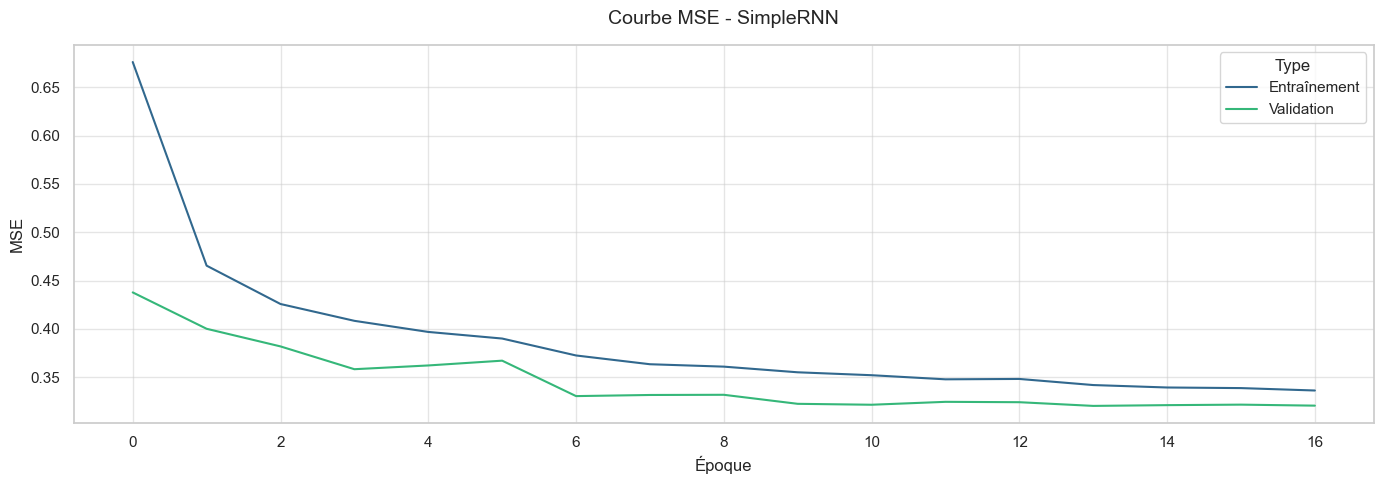

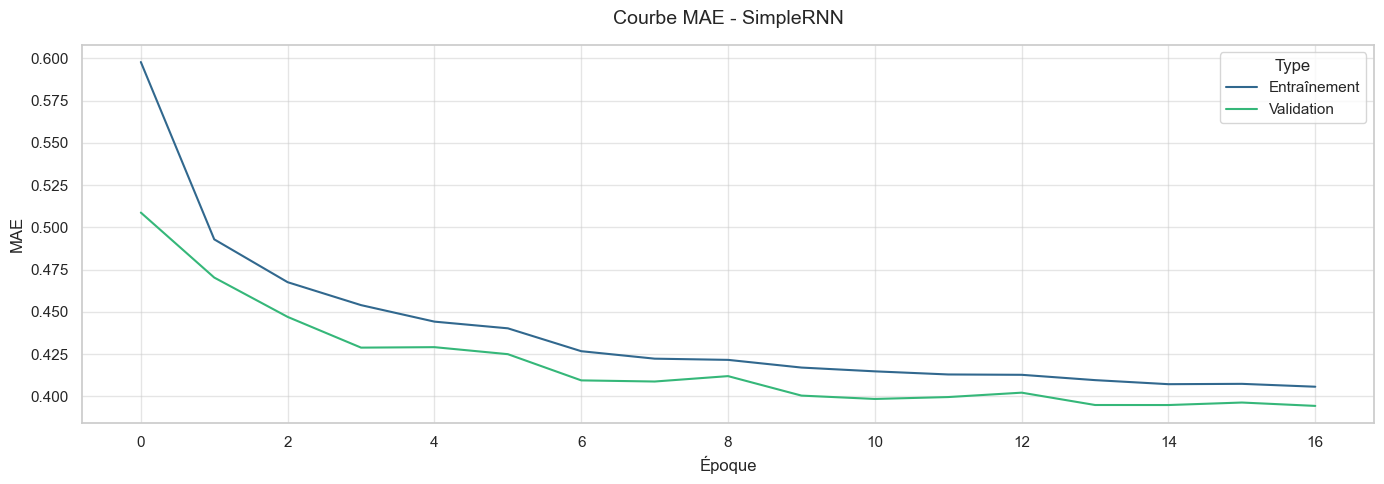

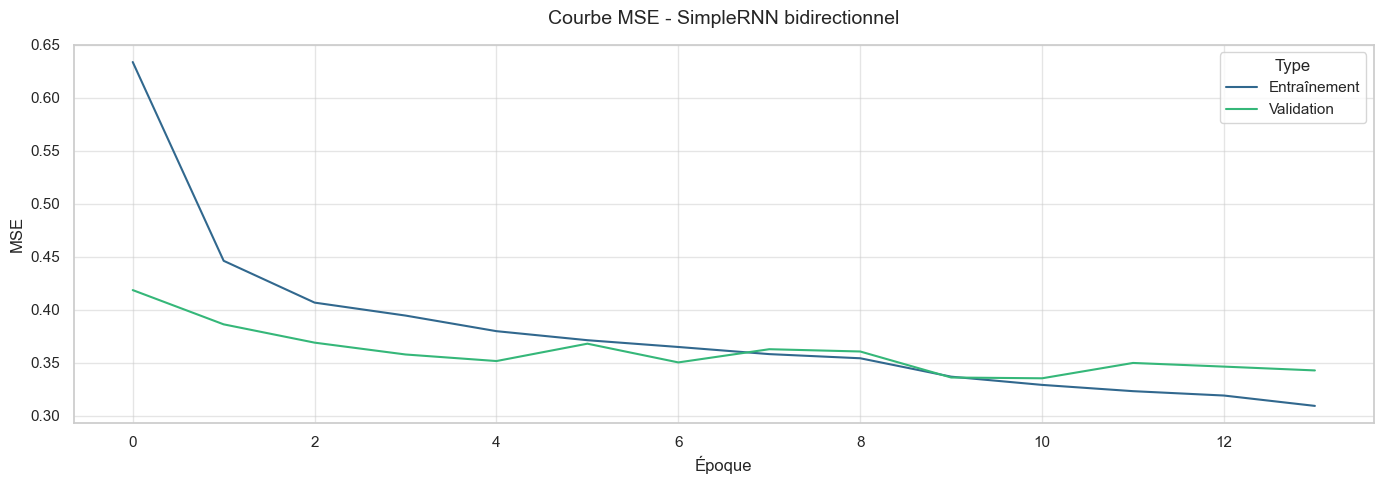

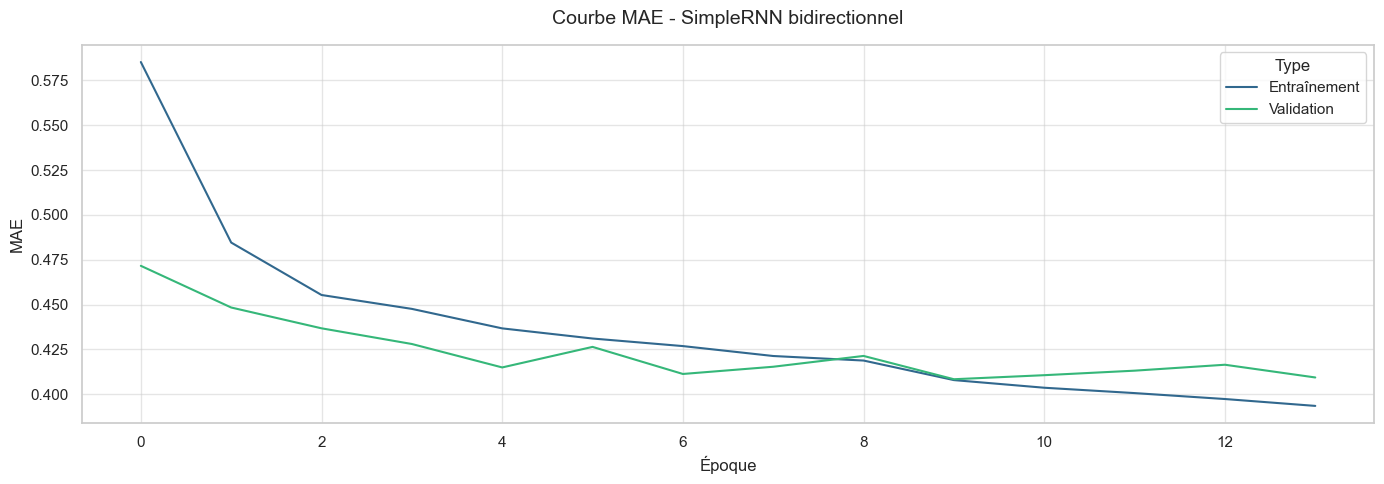

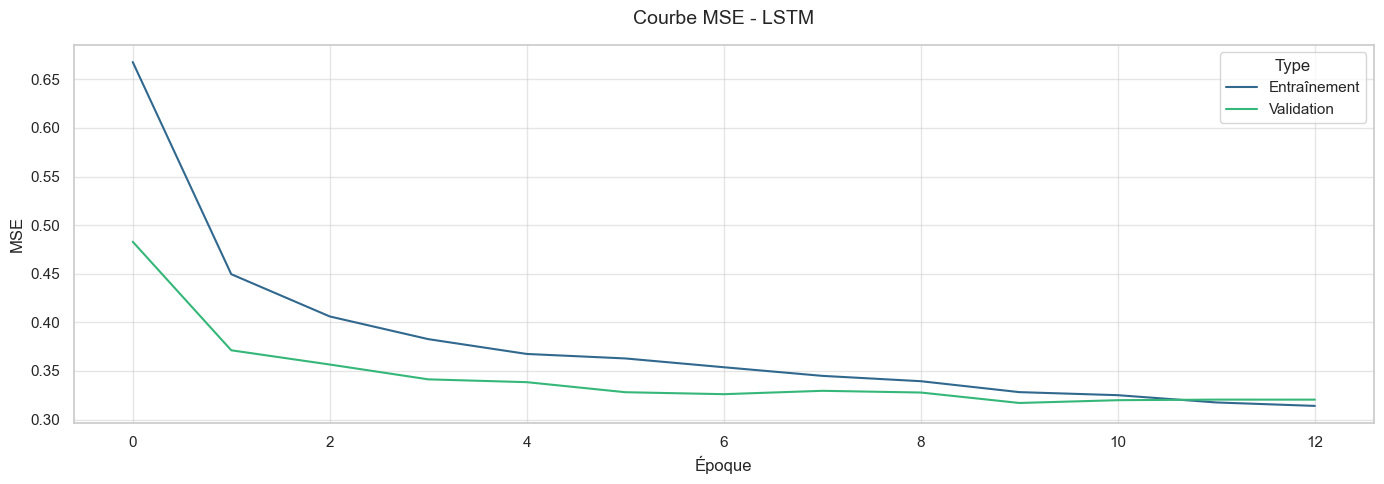

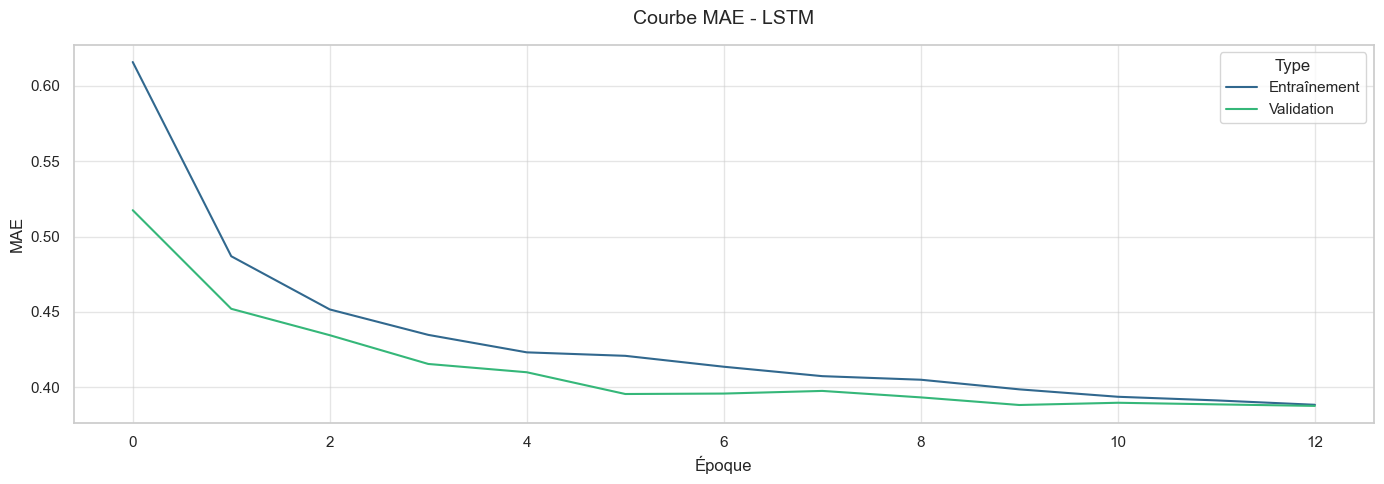

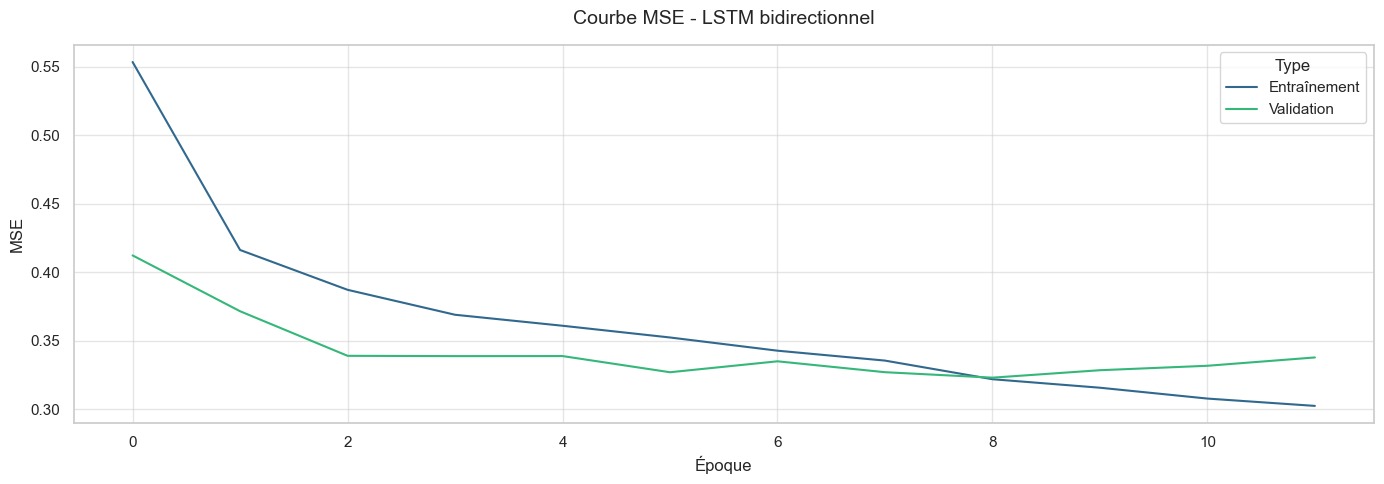

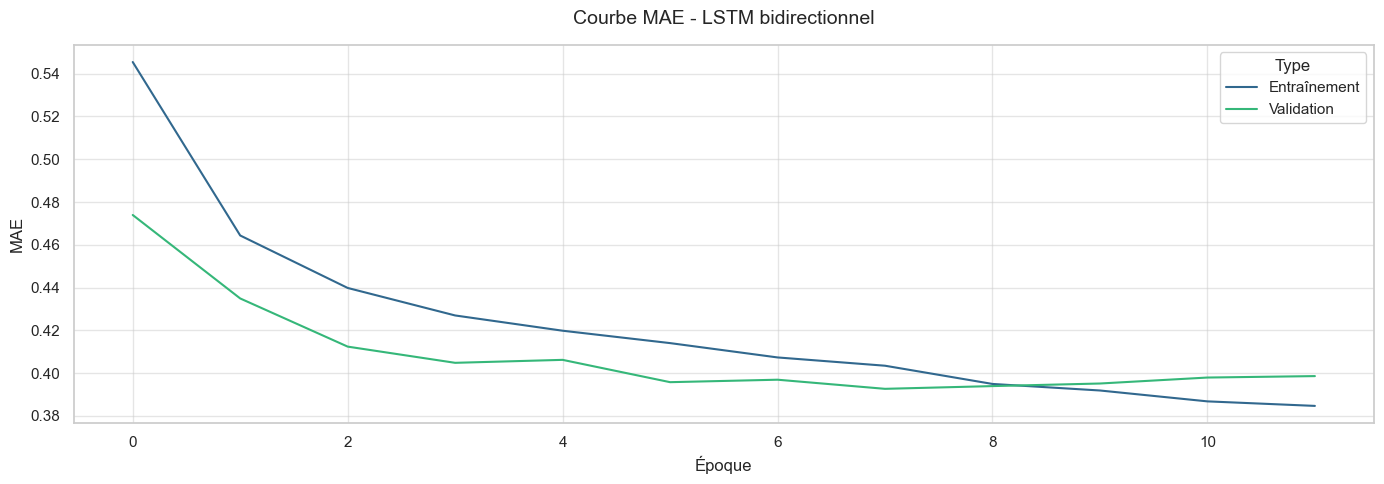

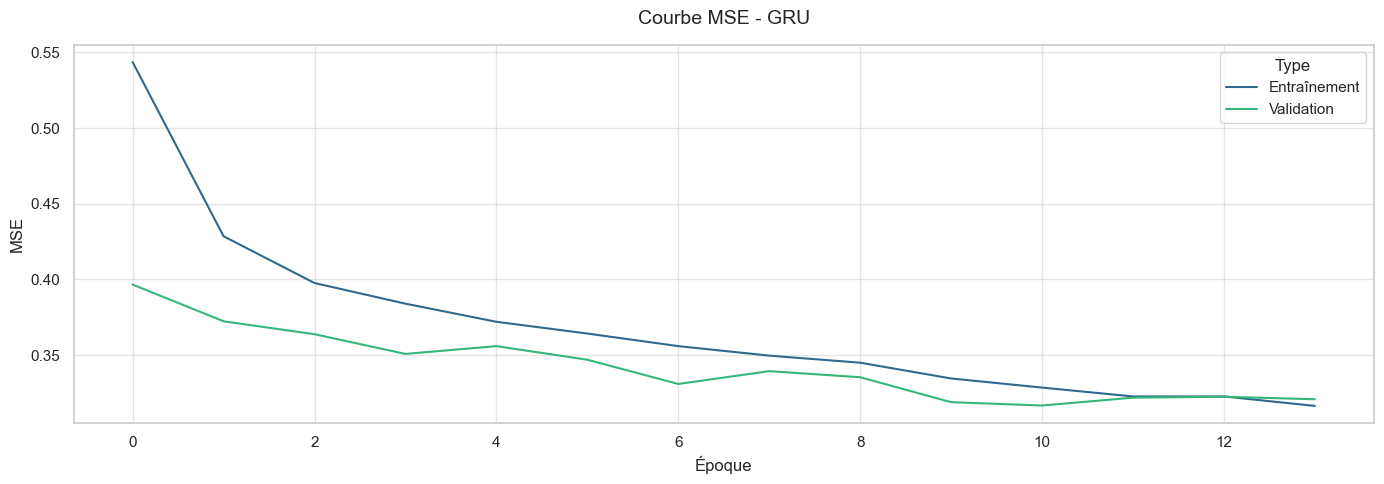

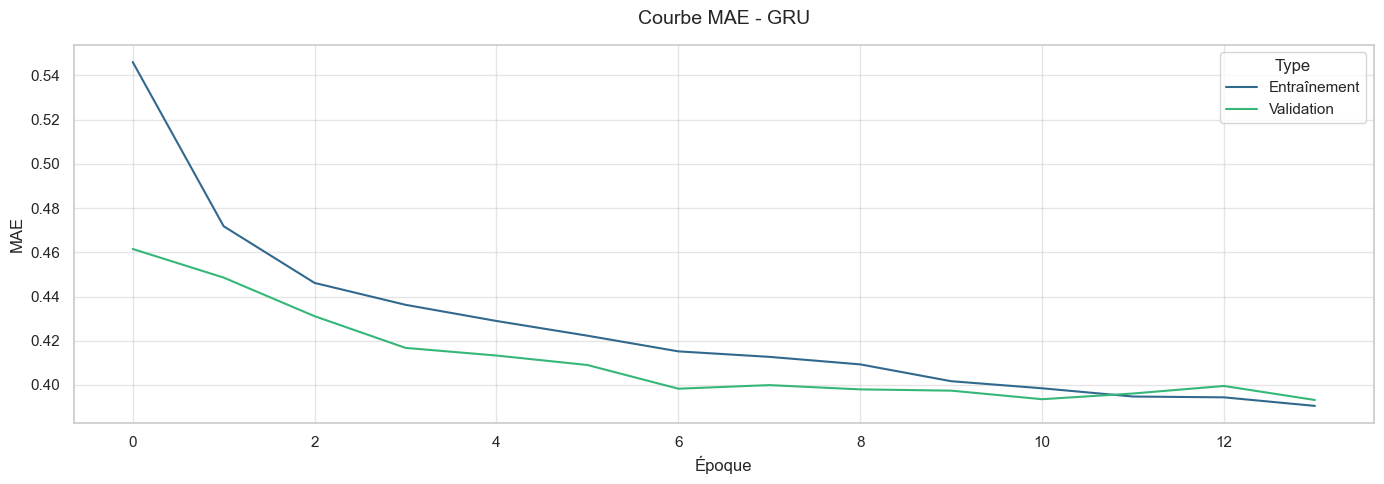

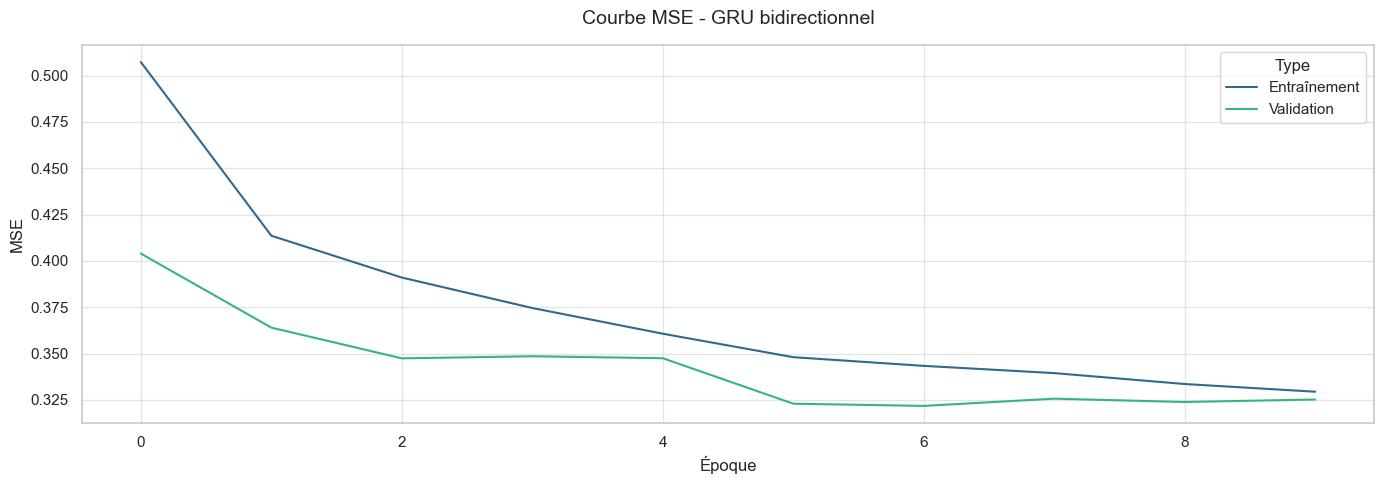

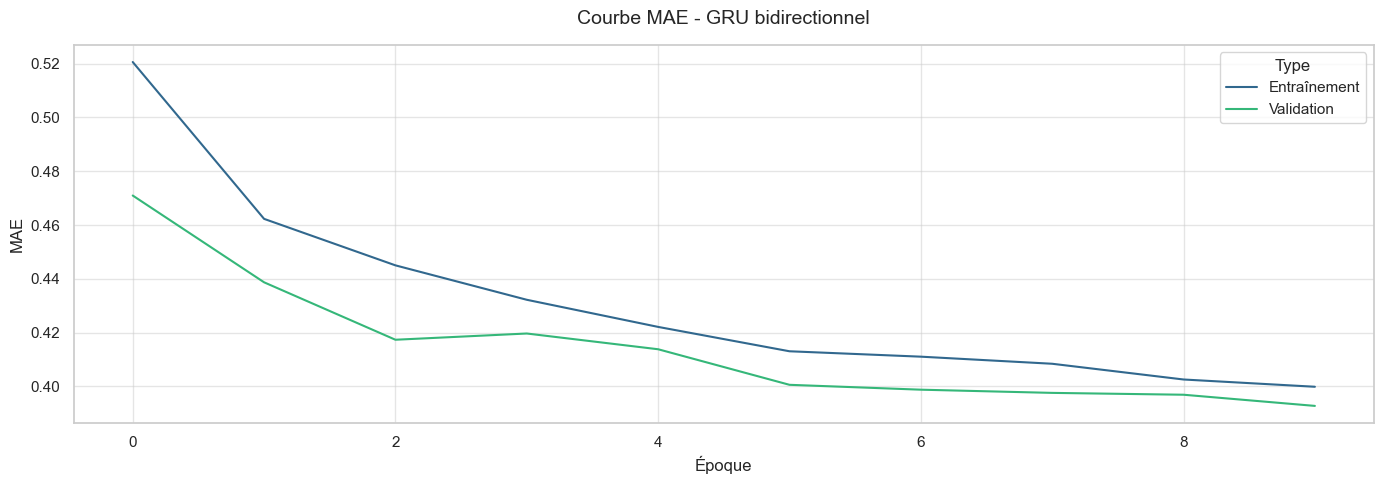

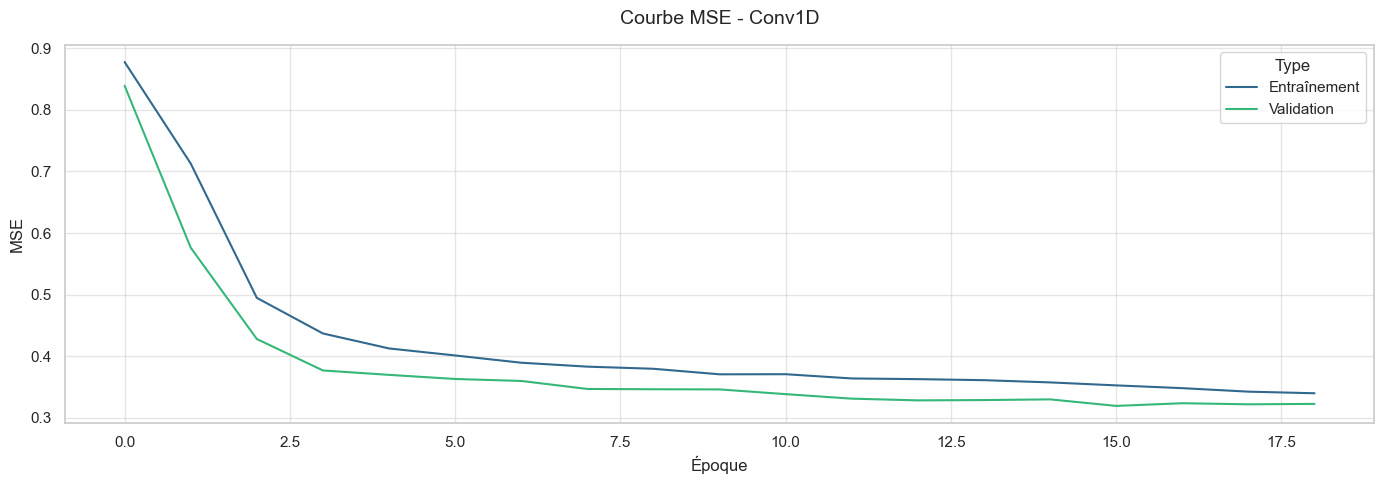

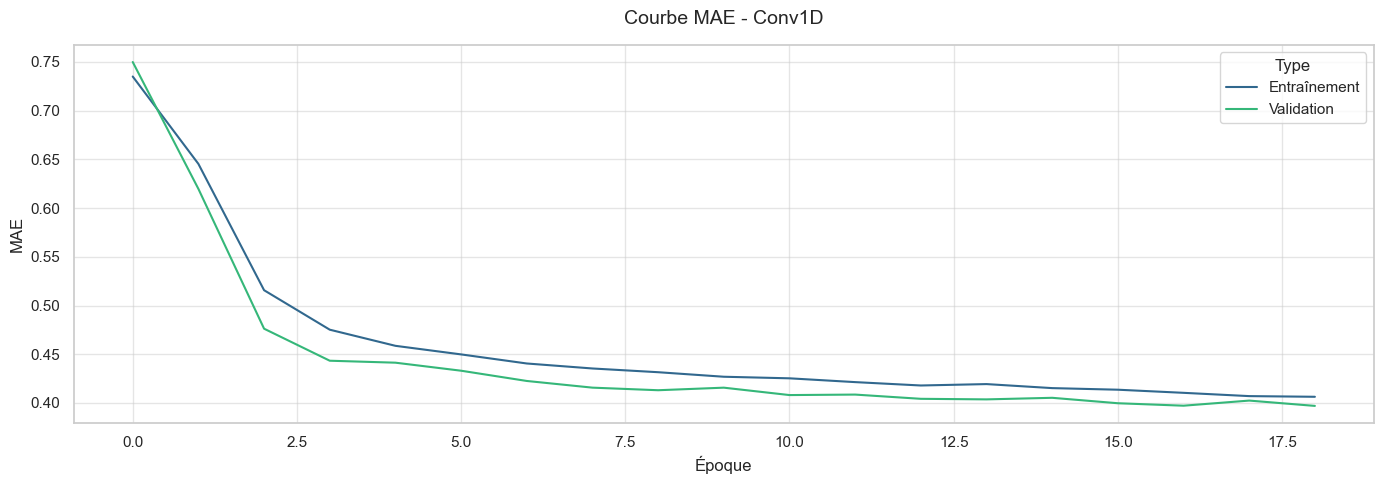

In [13]:
def plot_learning_curves(history, model_name):
    # Conversion de l'historique en DataFrame
    df_history = pd.DataFrame(history.history)
    df_history.index.name = "Epoch"
    df_history = df_history.reset_index()

    # Liste des paires de métriques à tracer
    metrics_list = [("loss", "val_loss", "MSE"), ("mae", "val_mae", "MAE")]

    for train_met, val_met, label in metrics_list:
        # Transformation en format long pour Seaborn
        df_history_melted = df_history.melt(id_vars="Epoch", value_vars=[train_met, val_met],
                                            var_name="Dataset", value_name=label)

        df_history_melted["Dataset"] = df_history_melted["Dataset"].replace({
            train_met: "Entraînement",
            val_met: "Validation"
        })

        sns.lineplot(data=df_history_melted, x="Epoch", y=label, hue="Dataset", palette="viridis")
        plt.title(f"Courbe {label} - {model_name}", fontsize=14, pad=15)
        plt.xlabel("Époque")
        plt.ylabel(label)
        plt.legend(title="Type")
        plt.tight_layout()
        plt.show()

plot_learning_curves(history_simple_rnn, "SimpleRNN")
plot_learning_curves(history_simple_rnn_bidirectional, "SimpleRNN bidirectionnel")
plot_learning_curves(history_lstm, "LSTM")
plot_learning_curves(history_lstm_bidirectional, "LSTM bidirectionnel")
plot_learning_curves(history_gru, "GRU")
plot_learning_curves(history_gru_bidirectional, "GRU bidirectionnel")
plot_learning_curves(history_conv1d, "Conv1D")

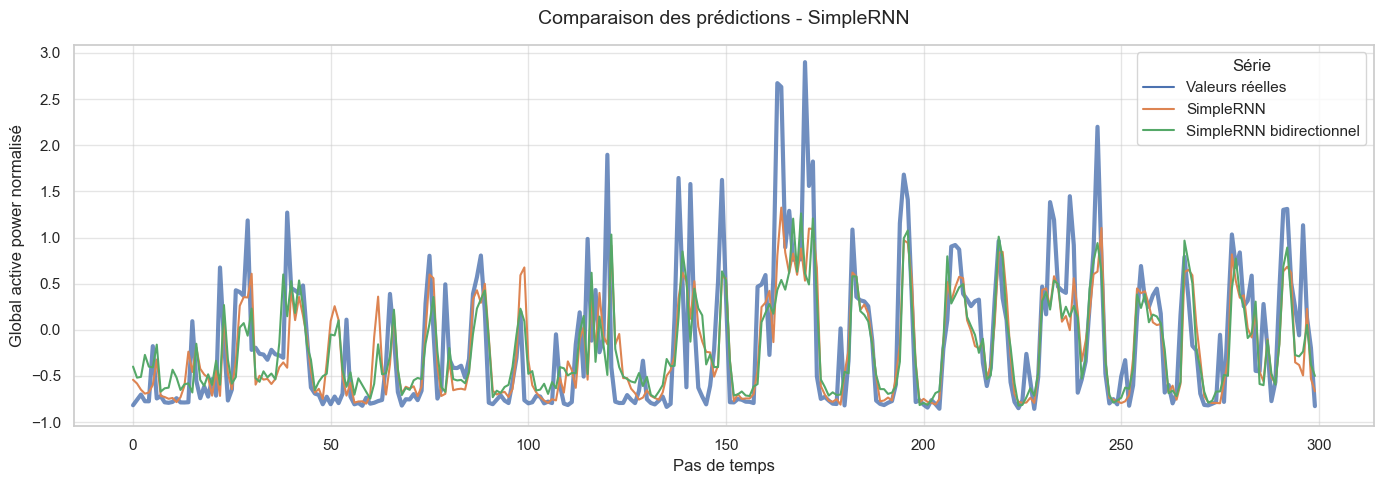

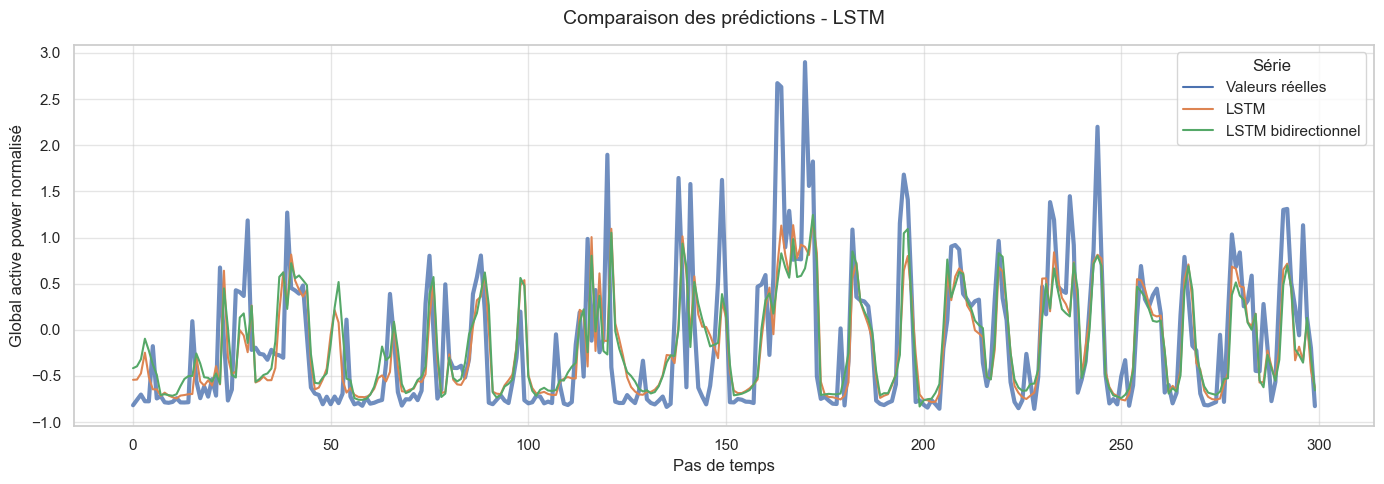

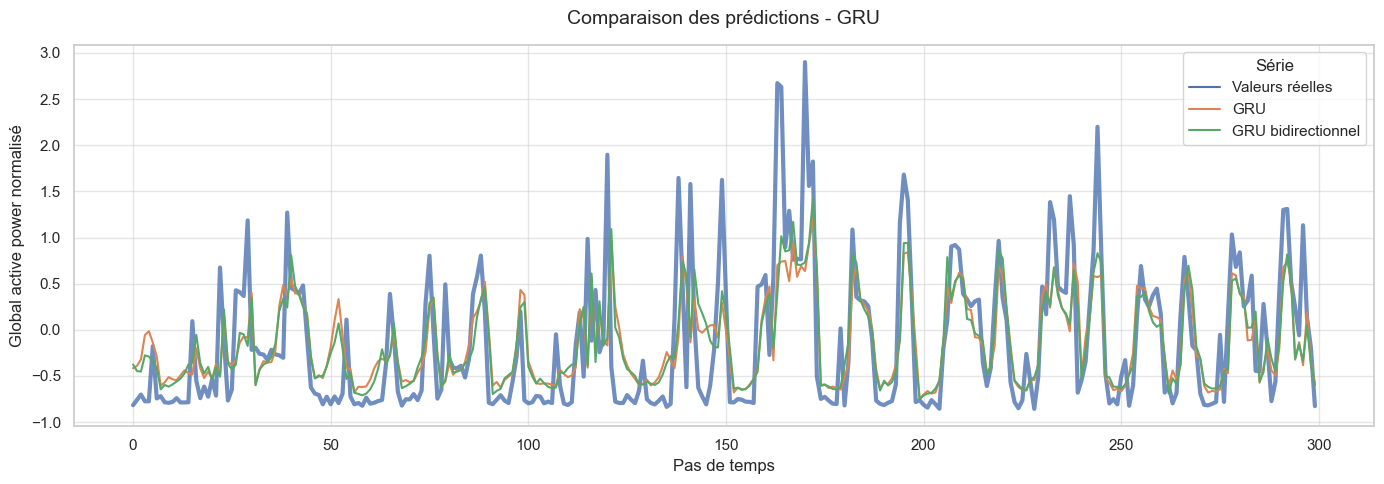

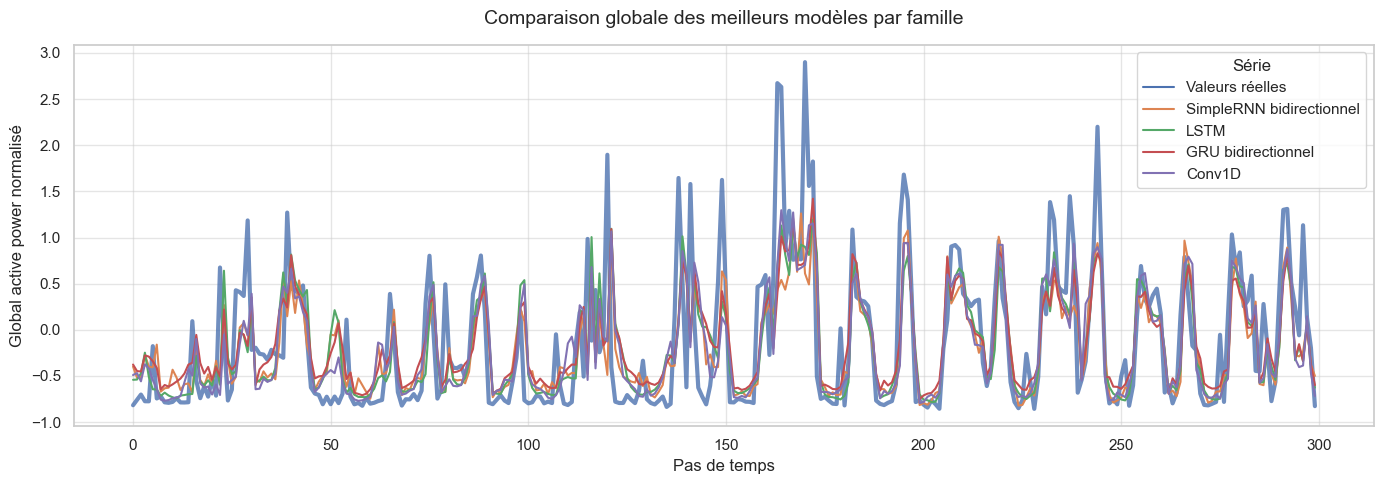

In [14]:
def get_predictions(model, dataset_test):
    y_true = []
    y_pred = []

    for x_batch_test, y_batch_test in dataset_test:
        preds = model.predict(x_batch_test, verbose=0)
        y_true.extend(y_batch_test.numpy())
        y_pred.extend(preds.flatten())

    return np.array(y_true), np.array(y_pred)


y_true_scaled, y_pred_simple_scaled = get_predictions(simple_rnn_baseline, test_ds)
_, y_pred_simple_bidirectional_scaled = get_predictions(simple_rnn_bidirectional, test_ds)

_, y_pred_lstm_scaled = get_predictions(lstm_model, test_ds)
_, y_pred_lstm_bidirectional_scaled = get_predictions(lstm_bidirectional_model, test_ds)

_, y_pred_gru_scaled = get_predictions(gru_model, test_ds)
_, y_pred_gru_bidirectional_scaled = get_predictions(gru_bidirectional_model, test_ds)

_, y_pred_conv1d_scaled = get_predictions(conv1d_model, test_ds)

def plot_predictions_comparison(title, predictions_dict, y_true, start=0, end=300):
    plot_data = pd.DataFrame({
        "Pas de temps": range(start, end),
        "Valeurs réelles": y_true[start:end]
    })

    for model_name, predictions in predictions_dict.items():
        plot_data[model_name] = predictions[start:end]

    df_melted = plot_data.melt(
        id_vars="Pas de temps",
        var_name="Série",
        value_name="Valeur"
    )

    plt.figure(figsize=(14, 5))

    ax = sns.lineplot(
        data=df_melted,
        x="Pas de temps",
        y="Valeur",
        hue="Série",
        linewidth=1.5
    )

    for line, label in zip(ax.lines, df_melted["Série"].unique()):
        if label == "Valeurs réelles":
            line.set_linewidth(3)
            line.set_alpha(0.8)

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("Pas de temps")
    plt.ylabel("Global active power normalisé")
    plt.tight_layout()
    plt.show()


start, end = 0, 300

plot_predictions_comparison(
    "Comparaison des prédictions - SimpleRNN",
    {
        "SimpleRNN": y_pred_simple_scaled,
        "SimpleRNN bidirectionnel": y_pred_simple_bidirectional_scaled
    },
    y_true_scaled,
    start,
    end
)

plot_predictions_comparison(
    "Comparaison des prédictions - LSTM",
    {
        "LSTM": y_pred_lstm_scaled,
        "LSTM bidirectionnel": y_pred_lstm_bidirectional_scaled
    },
    y_true_scaled,
    start,
    end
)

plot_predictions_comparison(
    "Comparaison des prédictions - GRU",
    {
        "GRU": y_pred_gru_scaled,
        "GRU bidirectionnel": y_pred_gru_bidirectional_scaled
    },
    y_true_scaled,
    start,
    end
)

plot_predictions_comparison(
    "Comparaison globale des meilleurs modèles par famille",
    {
        "SimpleRNN bidirectionnel": y_pred_simple_bidirectional_scaled,
        "LSTM": y_pred_lstm_scaled,
        "GRU bidirectionnel": y_pred_gru_bidirectional_scaled,
        "Conv1D": y_pred_conv1d_scaled
    },
    y_true_scaled,
    start,
    end
)

Le **GRU bidirectionnel** obtient la meilleure RMSE sur l'ensemble de test : `0.487221`.

Le **Conv1D** arrive juste derrière avec une RMSE de `0.489781`. Le **GRU classique**, le **LSTM** et le **LSTM bidirectionnel** restent dans des performances proches. Le **SimpleRNN** est le moins performant, même si sa version bidirectionnelle l'améliore nettement.

Ces résultats sont cohérents avec les architectures testées :

- les **LSTM** et **GRU** sont mieux adaptés que le SimpleRNN aux séries temporelles grâce à leurs mécanismes de portes ;
- le **Conv1D** donne aussi de très bons résultats, car il capture efficacement les motifs locaux dans la fenêtre de 24 heures ;
- l'ajout de `Bidirectional` améliore surtout le **SimpleRNN** et le **GRU**.

---

### Analyse des courbes d'apprentissage

Les courbes montrent un apprentissage correct : les pertes d'entraînement et de validation diminuent globalement, sans signe évident de surapprentissage.

#### SimpleRNN

Le **SimpleRNN** apprend vite au début, puis se stabilise. Sa version bidirectionnelle obtient de meilleurs résultats, car elle exploite la fenêtre temporelle dans les deux sens.

#### LSTM

Le **LSTM** obtient de bonnes performances. Le **LSTM bidirectionnel** fait légèrement mieux que le LSTM classique dans ce dernier entraînement, mais l'écart reste limité.

#### GRU

Le **GRU** obtient également de bons résultats. Sa version bidirectionnelle améliore le modèle classique et obtient la meilleure RMSE finale.

#### Conv1D

Le **Conv1D** obtient aussi de très bonnes performances. Il n'utilise pas de récurrence, mais il capture bien les variations locales.

Son intérêt est donc important : il est plus simple qu'un modèle récurrent bidirectionnel, tout en restant très performant.

L'`EarlyStopping` aide aussi à limiter le risque de surapprentissage.

---

### Analyse des prédictions

Les modèles suivent globalement la tendance générale de la consommation électrique. Les phases de faible consommation sont assez bien représentées, et plusieurs variations importantes sont détectées.

La principale faiblesse concerne les **pics de consommation**. Ils sont souvent sous-estimés, ce qui donne des prédictions plus lissées que les valeurs réelles. C'est assez classique dans ce type de problème, surtout quand les pics sont courts, irréguliers ou difficiles à anticiper.

Le **SimpleRNN bidirectionnel** suit mieux les variations que le SimpleRNN classique, mais il reste moins performant que les modèles **LSTM**, **GRU** et **Conv1D**.

Le **LSTM**, le **LSTM bidirectionnel**, le **GRU**, le **GRU bidirectionnel** et le **Conv1D** suivent mieux les variations que les modèles SimpleRNN. Aucun modèle ne prédit toutefois parfaitement les pics brusques.

---

### Comparaison finale des architectures

#### SimpleRNN

Le **SimpleRNN** sert de modèle de base. Il est simple, léger et rapide, mais il est moins adapté aux dépendances temporelles longues.

Le **SimpleRNN bidirectionnel** améliore le SimpleRNN classique en lisant chaque fenêtre temporelle dans les deux sens.

Il n'y a pas de fuite de données ici, car la valeur cible n'est pas incluse dans la fenêtre d'entrée : le modèle ne voit que les observations passées disponibles.

Cette version reste plus coûteuse qu'un SimpleRNN classique, car les couches récurrentes sont dupliquées dans les deux directions. Cela augmente le nombre de paramètres, le temps d'entraînement et éventuellement le risque de surapprentissage.

#### LSTM

Le **LSTM** obtient de bons résultats grâce à ses mécanismes de portes.

Le **LSTM bidirectionnel** fait un peu mieux que le LSTM classique dans ce dernier run, mais l'amélioration reste limitée.

#### GRU

Le **GRU** obtient des résultats proches du LSTM, avec une structure plus simple et moins de paramètres.

Sa version bidirectionnelle améliore clairement le résultat et obtient la meilleure RMSE. C'est donc le meilleur modèle selon la métrique principale.

#### Conv1D

Le **Conv1D** est l'autre résultat important. Il obtient la deuxième meilleure RMSE, devant les modèles LSTM et GRU classiques dans ce run.

Il constitue donc une alternative très pertinente : plus simple qu'un modèle récurrent, mais très efficace sur une fenêtre temporelle courte.

---

### Le cas de `Bidirectional`

Une couche `Bidirectional` lit la séquence dans les deux sens : du début vers la fin, puis de la fin vers le début. L'objectif est d'exploiter davantage les relations internes dans la fenêtre d'entrée.

Dans nos résultats, l'effet est surtout visible sur le **SimpleRNN** et le **GRU** :

| Modèle | RMSE |
|---|---:|
| SimpleRNN classique | `0.509558` |
| SimpleRNN bidirectionnel | `0.498874` |
| GRU classique | `0.497040` |
| GRU bidirectionnel | `0.487221` |

Pour le **LSTM**, l'amélioration existe dans ce dernier entraînement, mais elle est plus faible :

| Modèle | RMSE | MAE |
|---|---:|---:|
| LSTM classique | `0.499357` | `0.349961` |
| LSTM bidirectionnel | `0.495639` | `0.340389` |

Le LSTM bidirectionnel obtient une meilleure MAE, ce qui indique des erreurs absolues moyennes plus faibles. Le gain reste toutefois moins marqué que pour le GRU.

Au final, `Bidirectional` améliore le **SimpleRNN**, le **GRU** et légèrement le **LSTM** dans ce run. Son intérêt dépend donc du modèle utilisé.

Son utilisation reste acceptable dans notre cas : le modèle ne lit que la fenêtre historique disponible de 24 heures et ne voit pas la valeur future à prédire.

---

### Le cas du `Conv1D`

Le `Conv1D` ne parcourt pas la séquence pas à pas comme un SimpleRNN, un LSTM ou un GRU. Il applique des filtres sur des portions locales de la fenêtre temporelle.

C'est pertinent ici, car la consommation électrique contient des motifs courts :

- hausses rapides ;
- pics locaux ;
- retours à une consommation plus faible ;
- variations sur quelques heures.

Le **Conv1D** obtient :

| Métrique | Valeur |
|---|---:|
| RMSE | `0.489781` |
| MAE | `0.340151` |

Il se place donc juste derrière le GRU bidirectionnel.

Son intérêt principal est son **rapport simplicité/performance**. Il ne modélise pas explicitement les dépendances temporelles longues, mais il capture très bien les motifs locaux dans une fenêtre de 24 heures.

---

### Limites du travail

#### Rééchantillonnage horaire

Le dataset original contient des mesures à la minute, mais nous avons utilisé une moyenne par heure pour réduire le volume de données et le temps d'entraînement.

Cela simplifie le problème, mais fait perdre des variations très courtes.

#### Pics de consommation

Les modèles ont tendance à lisser les prédictions et à sous-estimer certains pics importants, parfois difficiles à prévoir uniquement à partir des 24 heures précédentes.

#### Taille de la fenêtre temporelle

Nous avons utilisé une fenêtre de 24 heures pour capturer un cycle journalier. D'autres fenêtres, comme 48 ou 72 heures, pourraient être testées.

#### Bidirectional

Cette variante augmente le nombre de paramètres et le temps d'entraînement. Elle peut aussi augmenter le risque de surapprentissage si le modèle devient trop complexe.

#### Métriques normalisées

Les métriques sont calculées sur des données normalisées. Elles permettent de comparer les modèles entre eux, mais elles sont moins directement interprétables dans l'unité réelle de `Global_active_power`.

---

## Conclusion

Le **GRU bidirectionnel** est le meilleur modèle selon la RMSE. Le **Conv1D** arrive juste derrière, avec une architecture plus simple et non récurrente.

Classement général :

| Rang | Modèle | Commentaire |
|---:|---|---|
| 1 | GRU bidirectionnel | meilleur résultat global |
| 2 | Conv1D | très bon rapport simplicité/performance |
| 3 | GRU, LSTM, LSTM bidirectionnel | résultats proches |
| 4 | SimpleRNN | moins performant, malgré l'amélioration bidirectionnelle |

`Bidirectional` améliore surtout le SimpleRNN et le GRU. Il améliore aussi légèrement le LSTM dans ce dernier entraînement, mais le gain reste moins important.

Le **Conv1D** est l'ajout le plus intéressant en dehors des modèles récurrents. Il montre qu'une architecture plus simple peut obtenir d'excellents résultats si elle capture bien les motifs locaux de la fenêtre temporelle.

Les prédictions restent globalement correctes sur la tendance générale, mais les pics brusques sont souvent sous-estimés. C'est la limite principale observée sur l'ensemble des modèles.